In [11]:
import os
import re
import csv
from collections import defaultdict
from statistics import mean

def parse_log_file_last_metrics(path):
    """从 log 文件末尾提取最后一次 eval 的指标（支持科学计数法）"""
    eval_metrics = {}
    with open(path, encoding="utf-8") as f:
        lines = f.readlines()

    i = len(lines) - 1
    while i >= 0:
        if lines[i].strip().startswith("start to eval"):
            # hit20
            if i + 1 < len(lines) and lines[i+1].startswith("hit20"):
                m = re.search(r"hit20\s+([0-9.+-eE]+)", lines[i+1])
                if m:
                    eval_metrics["hit20"] = float(m.group(1))
            # hit50
            if i + 2 < len(lines) and lines[i+2].startswith("hit50"):
                m = re.search(r"hit50\s+([0-9.+-eE]+)", lines[i+2])
                if m:
                    eval_metrics["hit50"] = float(m.group(1))
            # hit100
            if i + 3 < len(lines) and lines[i+3].startswith("hit100"):
                m = re.search(r"hit100\s+([0-9.+-eE]+)", lines[i+3])
                if m:
                    eval_metrics["hit100"] = float(m.group(1))
            # pr_auc 等
            if i + 4 < len(lines) and lines[i+4].startswith("roc_auc"):
                nums = re.findall(r"[-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?", lines[i+4])
                if len(nums) >= 4:
                    fields = ['roc_auc', 'pr_auc', 'f1', 'mrr']
                    result_dict = dict(zip(fields, map(float, nums[-4:])))
                    eval_metrics.update(result_dict)
            if eval_metrics:
                break
        i -= 1
    return eval_metrics


# ==== 用户指定参数 ====
dataset = "twitter"
ratios = [0.3]
# cs = [1, 2, 3]
# convergences = [0.6, 0.7, 0.8, 0.9]
# pos_ratios = [0.6, 0.8, 1.0, 1.2]
cs = [1]
convergences = [0.7]
pos_ratios = [0.6, 0.8, 1.0, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 
              1.8, 1.9, 2.0, 2.15, 2.30, 2.45, 2.60, 2.75, 2.90, 
              3.05, 3.20, 3.4, 3.6, 3.8, 4.0, 4.3, 4.6, 4.9, 
              5.0, 5.2, 5.4, 5.8, 6.2, 6.6, 7.0, 7.4, 7.8,
              8, 9, 10, 11, 12, 13, 14, 15]

seed = 1

log_base_dir = "."
output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)

ALL_METRICS = ['hit20', 'hit50', 'hit100', 'pr_auc', 'f1', 'mrr']

metric_bucket = defaultdict(list)
metric_keys = set()

# ==== 解析日志 ====
for ratio in ratios:
    for c in cs:
        for conv in convergences:
            for pr in pos_ratios:
                fname = f"r{ratio}_c{c}_conv{conv}_pr{pr}_seed{seed}.log"
                log_path = os.path.join(log_base_dir, fname)
                key = (ratio, c, conv, pr)

                if not os.path.isfile(log_path):
                    print(f"[WARN] 缺失: {log_path}")
                    metrics = {k: 0.0 for k in ALL_METRICS}
                    metric_bucket[key].append(metrics)
                    metric_keys.update(metrics.keys())
                    continue

                metrics = parse_log_file_last_metrics(log_path)
                if not metrics:
                    print(f"[WARN] 无指标: {log_path}")
                    metrics = {k: 0.0 for k in ALL_METRICS}
                metric_bucket[key].append(metrics)
                metric_keys.update(metrics.keys())

# ==== 写入 CSV ====
csv_path = os.path.join(output_dir, f"{dataset}_grid_result.csv")
metric_keys = sorted(metric_keys)
header = ["split_ratio", "c", "convergence", "pos_ratio"] + metric_keys

with open(csv_path, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=header)
    writer.writeheader()
    for key, metrics_list in metric_bucket.items():
        ratio, c, conv, pr = key
        row = {"split_ratio": ratio, "c": c, "convergence": conv, "pos_ratio": pr}
        for k in metric_keys:
            vals = [m[k] for m in metrics_list if k in m]
            row[k] = f"{round(round(mean(vals), 4) * 100, 2)}" if vals else "0.0"
        writer.writerow(row)

print(f"[INFO] 写入完毕: {csv_path}")


[INFO] 写入完毕: ./results/twitter_grid_result.csv


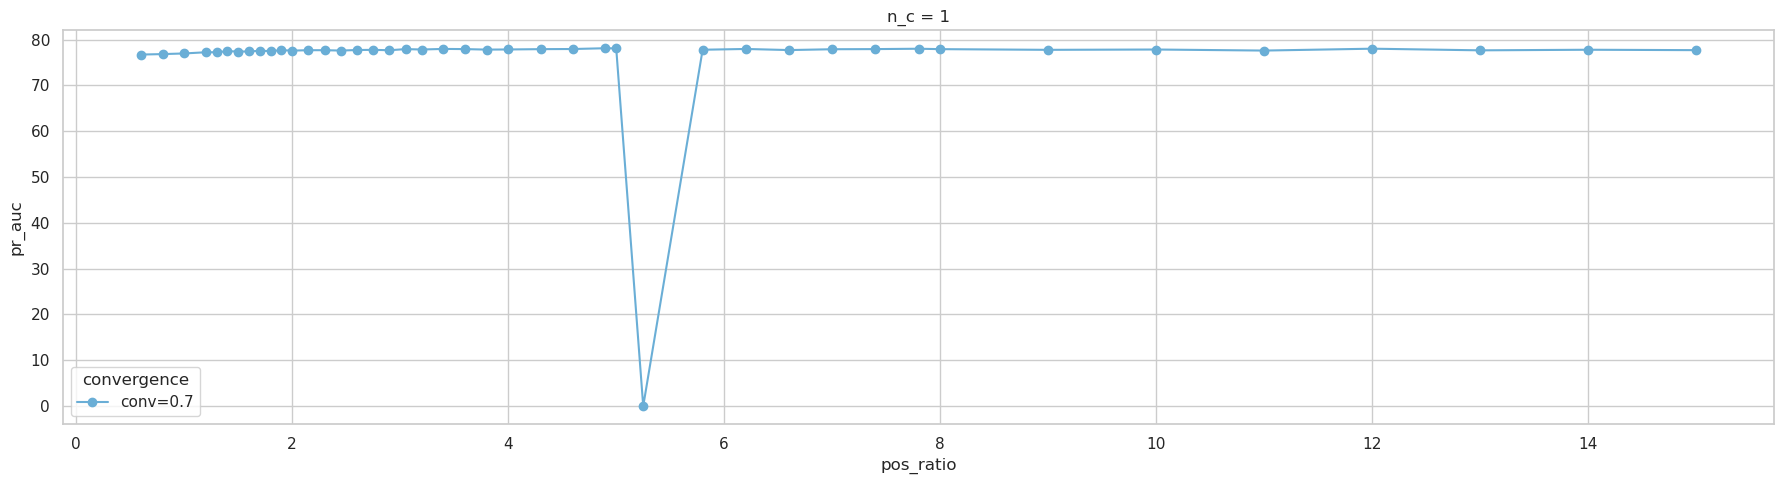

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 读取数据 ===
csv_path = "./results/twitter_grid_result.csv"
df = pd.read_csv(csv_path)
df["pr_auc"] = df["pr_auc"].astype(float)

# === 绘制图表 ===
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, len(cs), figsize=(18, 5))
if len(cs) != 1:
    axes = axes.flatten()
else:
    axes = [axes]

palette = sns.color_palette("Blues", n_colors=len(df["convergence"].unique()))

for idx, c in enumerate(sorted(df["c"].unique())):
    ax = axes[idx]
    subdf = df[df["c"] == c]

    for i, conv in enumerate(sorted(subdf["convergence"].unique())):
        subsub = subdf[subdf["convergence"] == conv].sort_values("pos_ratio")
        ax.plot(
            subsub["pos_ratio"],
            subsub["pr_auc"],
            marker="o",
            color=palette[i],
            label=f"conv={conv}"
        )
    ax.set_title(f"n_c = {c}")
    ax.set_xlabel("pos_ratio")
    ax.set_ylabel("pr_auc")
    ax.legend(title="convergence")
    ax.grid(True)

plt.tight_layout()
plt.show()
